In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Ganti path sesuai lokasi file kamu
df = pd.read_excel('Kelas G_Fixed Call Report ~rapih.xlsx')

# Atur urutan bulan supaya grafik tampil berurutan
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

print(df.head())

   Year Month  Total Number of Calls  Total Number of Doctors Consultancy  \
0  2025   Feb                 155200                                98964   
1  2025   Jan                 130982                                87815   
2  2024   Dec                 133725                                86832   
3  2024   Nov                 153698                                93710   
4  2024   Oct                 214604                               108207   

   Number of Total Health Information  Number of Total Ambulance Information  \
0                                3777                                   5773   
1                                3217                                   4179   
2                                3634                                   3735   
3                                3010                                   4421   
4                                6307                                   5792   

   Number of Total Complaints  Number of Calls To Know A

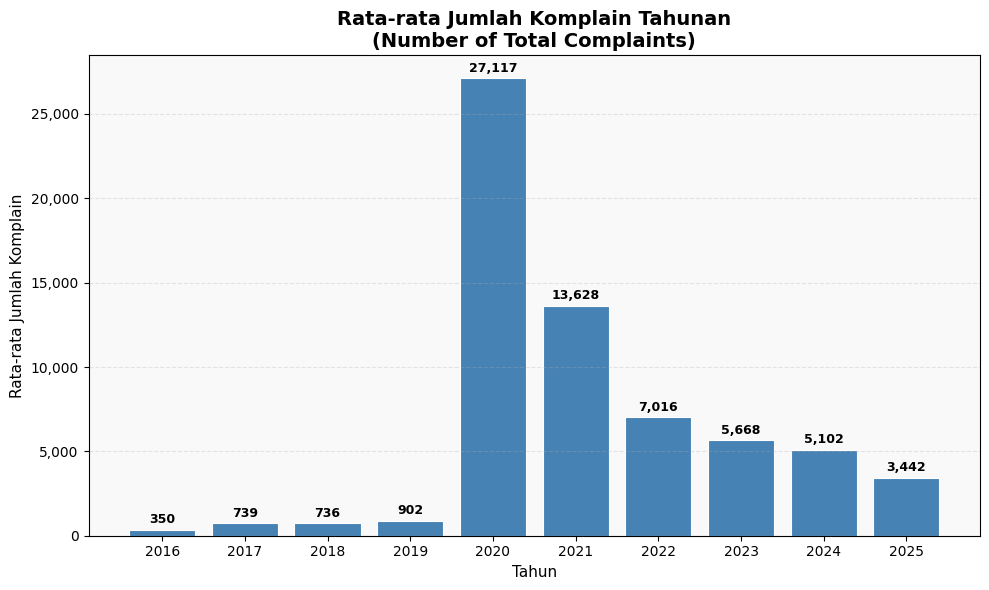

In [9]:
fig1, ax1 = plt.subplots(figsize=(10, 6))

# Hitung rata-rata komplain per tahun dengan groupby
avg_complaints = df.groupby('Year')['Number of Total Complaints'].mean().reset_index()
avg_complaints.columns = ['Year', 'Avg_Complaints']

# Buat bar chart
bars = ax1.bar(
    avg_complaints['Year'].astype(str),
    avg_complaints['Avg_Complaints'],
    color='steelblue',
    edgecolor='white',
    linewidth=0.8
)

# Tambahkan label nilai di atas setiap bar
for bar, val in zip(bars, avg_complaints['Avg_Complaints']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{val:,.0f}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax1.set_title('Rata-rata Jumlah Komplain Tahunan\n(Number of Total Complaints)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tahun', fontsize=11)
ax1.set_ylabel('Rata-rata Jumlah Komplain', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

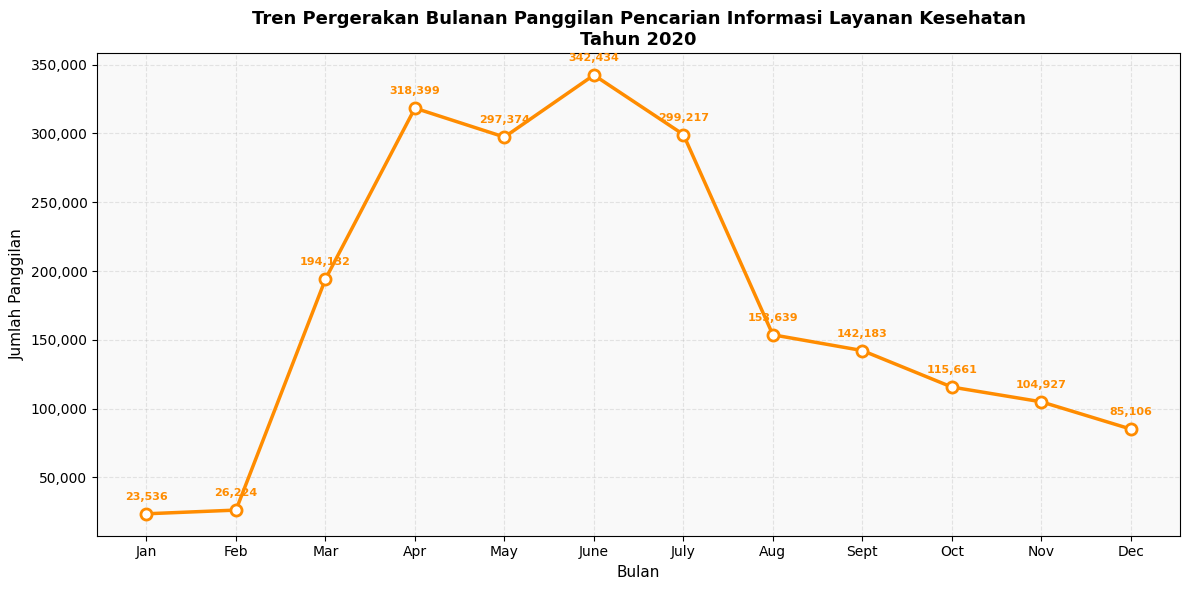

In [10]:
fig2, ax2 = plt.subplots(figsize=(12, 6))

# Filter hanya tahun 2020 dan urutkan berdasarkan bulan
df_2020 = df[df['Year'] == 2020].sort_values('Month')

# Buat line chart
ax2.plot(
    df_2020['Month'],
    df_2020['Number of Calls To Know About The Service'],
    marker='o',
    color='darkorange',
    linewidth=2.5,
    markersize=8,
    markerfacecolor='white',
    markeredgecolor='darkorange',
    markeredgewidth=2
)

# Tambahkan label nilai di setiap titik
for _, row in df_2020.iterrows():
    ax2.annotate(
        f"{row['Number of Calls To Know About The Service']:,.0f}",
        (row['Month'], row['Number of Calls To Know About The Service']),
        textcoords='offset points', xytext=(0, 10),
        ha='center', fontsize=8, color='darkorange', fontweight='bold'
    )

ax2.set_title('Tren Pergerakan Bulanan Panggilan Pencarian Informasi Layanan Kesehatan\nTahun 2020', fontsize=13, fontweight='bold')
ax2.set_xlabel('Bulan', fontsize=11)
ax2.set_ylabel('Jumlah Panggilan', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

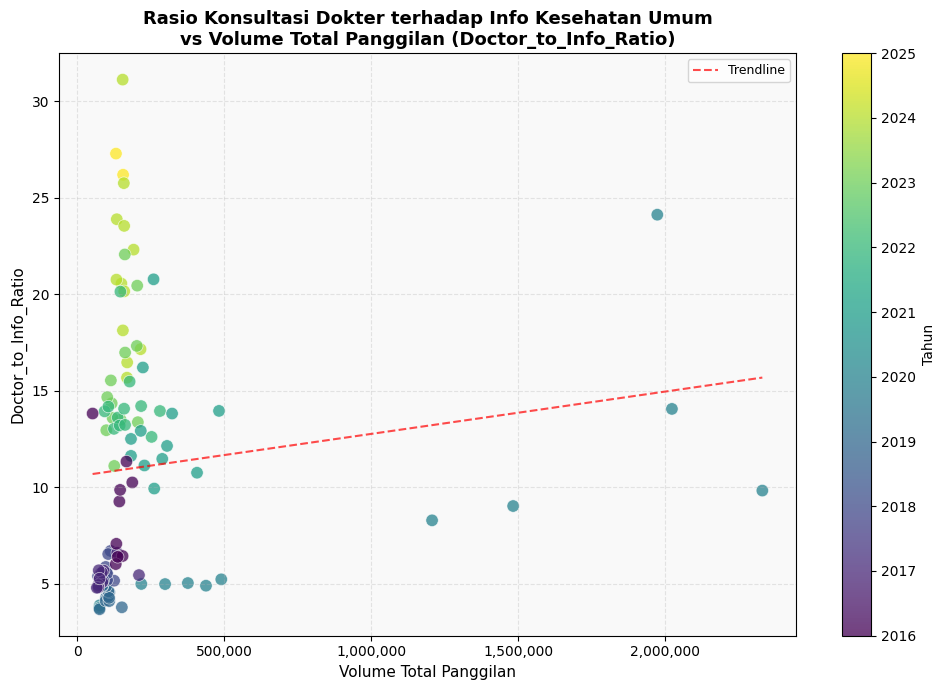

In [11]:
fig3, ax3 = plt.subplots(figsize=(10, 7))

# Buat kolom baru Doctor_to_Info_Ratio
df['Doctor_to_Info_Ratio'] = (
    df['Total Number of Doctors Consultancy'] / df['Number of Total Health Information']
)

# Scatter plot dengan warna berdasarkan tahun
scatter = ax3.scatter(
    df['Total Number of Calls'],
    df['Doctor_to_Info_Ratio'],
    c=df['Year'],
    cmap='viridis',
    alpha=0.75,
    s=80,
    edgecolors='white',
    linewidth=0.5
)

# Colorbar untuk keterangan tahun
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Tahun', fontsize=10)
cbar.set_ticks(sorted(df['Year'].unique()))

# Tambahkan trendline
z = np.polyfit(df['Total Number of Calls'], df['Doctor_to_Info_Ratio'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Total Number of Calls'].min(), df['Total Number of Calls'].max(), 200)
ax3.plot(x_line, p(x_line), 'r--', linewidth=1.5, alpha=0.7, label='Trendline')
ax3.legend(fontsize=9)

ax3.set_title('Rasio Konsultasi Dokter terhadap Info Kesehatan Umum\nvs Volume Total Panggilan (Doctor_to_Info_Ratio)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Volume Total Panggilan', fontsize=11)
ax3.set_ylabel('Doctor_to_Info_Ratio', fontsize=11)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax3.grid(alpha=0.3, linestyle='--')
ax3.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

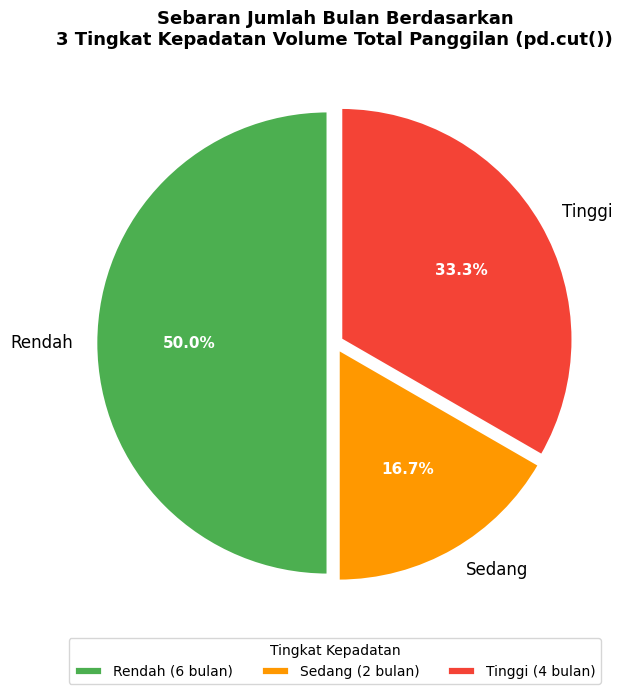

In [12]:
fig4, ax4 = plt.subplots(figsize=(9, 7))

# Hitung total panggilan per bulan (semua tahun digabung)
monthly_total = df.groupby('Month', observed=True)['Total Number of Calls'].sum().reset_index()
monthly_total.columns = ['Month', 'Total_Calls']

# Bagi ke 3 tingkat kepadatan menggunakan pd.cut()
monthly_total['Density_Level'] = pd.cut(
    monthly_total['Total_Calls'],
    bins=3,
    labels=['Rendah', 'Sedang', 'Tinggi']
)

# Hitung jumlah bulan per tingkat kepadatan
density_count = monthly_total['Density_Level'].value_counts().reindex(['Rendah', 'Sedang', 'Tinggi'])

# Buat pie chart
colors = ['#4CAF50', '#FF9800', '#F44336']
wedges, texts, autotexts = ax4.pie(
    density_count,
    labels=density_count.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=[0.03, 0.03, 0.03],
    startangle=90,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
    at.set_color('white')

# Legend dengan jumlah bulan
legend_labels = [f'{level} ({count} bulan)' for level, count in zip(density_count.index, density_count.values)]
ax4.legend(wedges, legend_labels, title='Tingkat Kepadatan', loc='lower center',
           bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=10)

ax4.set_title('Sebaran Jumlah Bulan Berdasarkan\n3 Tingkat Kepadatan Volume Total Panggilan (pd.cut())', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

✅ Data berhasil dimuat!
   Jumlah baris: 107
   Kolom: ['Year', 'Month', 'Total Number of Calls', 'Total Number of Doctors Consultancy', 'Number of Total Health Information', 'Number of Total Ambulance Information', 'Number of Total Complaints', 'Number of Calls To Know About The Service']



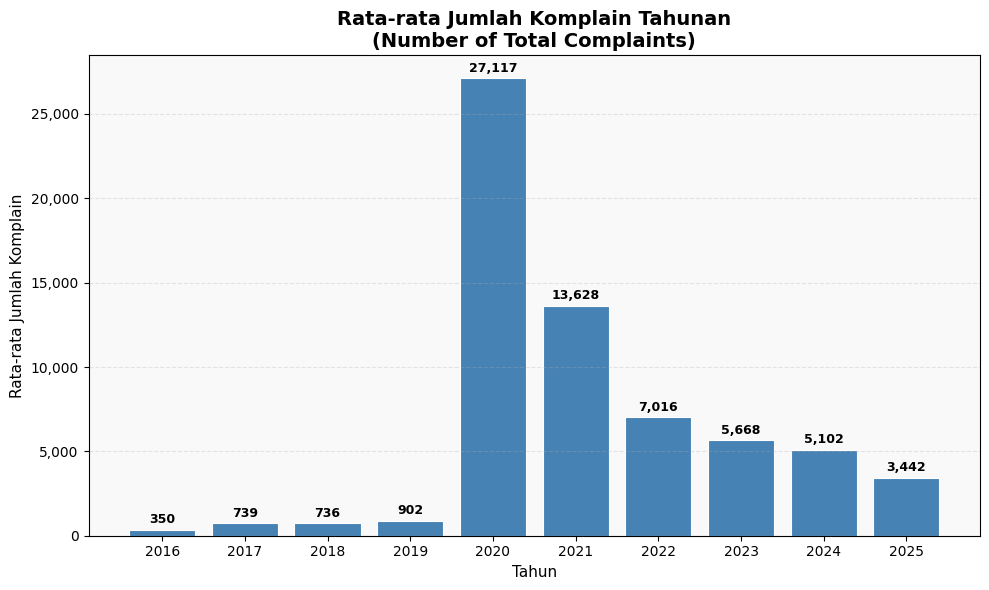

✅ Soal 1 selesai!



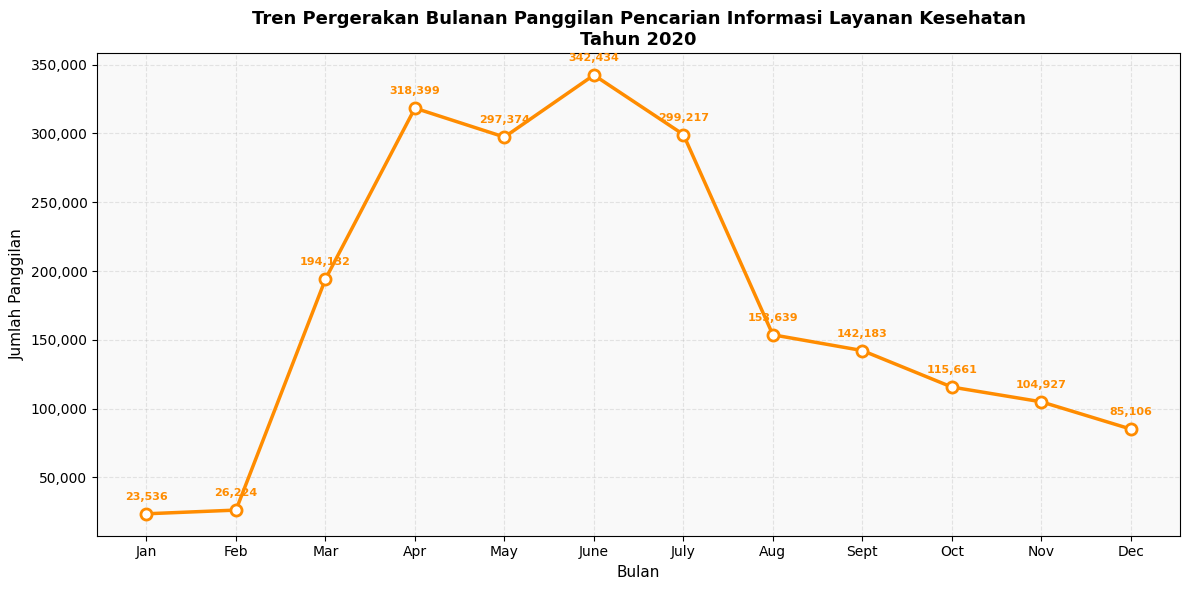

✅ Soal 2 selesai!



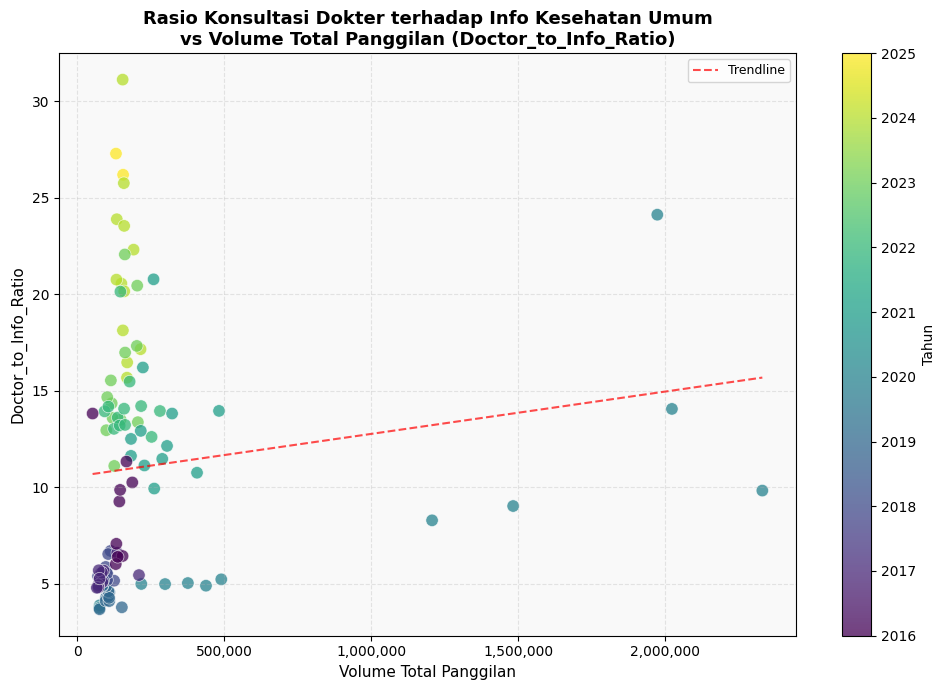

✅ Soal 3 selesai!



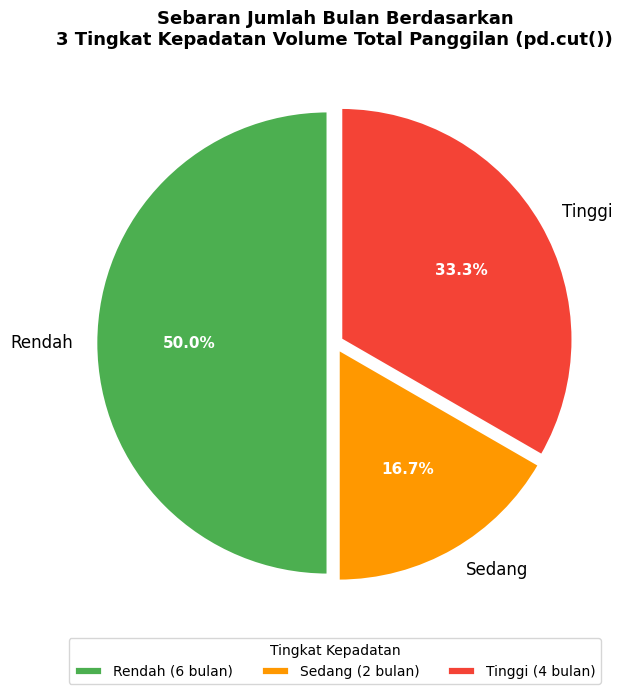

✅ Soal 4 selesai!

🎉 Semua soal selesai! Grafik tersimpan di folder yang sama.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_excel('Kelas G_Fixed Call Report ~rapih.xlsx')

# Atur urutan bulan
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

print("✅ Data berhasil dimuat!")
print(f"   Jumlah baris: {len(df)}")
print(f"   Kolom: {df.columns.tolist()}\n")


# ============================================================
# SOAL 1 — Bar Chart: Rata-rata Komplain Tahunan
# ============================================================
fig1, ax1 = plt.subplots(figsize=(10, 6))

avg_complaints = df.groupby('Year')['Number of Total Complaints'].mean().reset_index()
avg_complaints.columns = ['Year', 'Avg_Complaints']

bars = ax1.bar(
    avg_complaints['Year'].astype(str),
    avg_complaints['Avg_Complaints'],
    color='steelblue',
    edgecolor='white',
    linewidth=0.8
)

for bar, val in zip(bars, avg_complaints['Avg_Complaints']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{val:,.0f}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax1.set_title('Rata-rata Jumlah Komplain Tahunan\n(Number of Total Complaints)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tahun', fontsize=11)
ax1.set_ylabel('Rata-rata Jumlah Komplain', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('soal1_bar_komplain_tahunan.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Soal 1 selesai!\n")


# ============================================================
# SOAL 2 — Line Chart: Tren Bulanan Info Kesehatan Tahun 2020
# ============================================================
fig2, ax2 = plt.subplots(figsize=(12, 6))

df_2020 = df[df['Year'] == 2020].sort_values('Month')

ax2.plot(
    df_2020['Month'],
    df_2020['Number of Calls To Know About The Service'],
    marker='o',
    color='darkorange',
    linewidth=2.5,
    markersize=8,
    markerfacecolor='white',
    markeredgecolor='darkorange',
    markeredgewidth=2
)

for _, row in df_2020.iterrows():
    ax2.annotate(
        f"{row['Number of Calls To Know About The Service']:,.0f}",
        (row['Month'], row['Number of Calls To Know About The Service']),
        textcoords='offset points', xytext=(0, 10),
        ha='center', fontsize=8, color='darkorange', fontweight='bold'
    )

ax2.set_title('Tren Pergerakan Bulanan Panggilan Pencarian Informasi Layanan Kesehatan\nTahun 2020', fontsize=13, fontweight='bold')
ax2.set_xlabel('Bulan', fontsize=11)
ax2.set_ylabel('Jumlah Panggilan', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('soal2_line_info_kesehatan_2020.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Soal 2 selesai!\n")


# ============================================================
# SOAL 3 — Scatter Plot: Doctor_to_Info_Ratio vs Total Panggilan
# ============================================================
fig3, ax3 = plt.subplots(figsize=(10, 7))

df['Doctor_to_Info_Ratio'] = (
    df['Total Number of Doctors Consultancy'] / df['Number of Total Health Information']
)

scatter = ax3.scatter(
    df['Total Number of Calls'],
    df['Doctor_to_Info_Ratio'],
    c=df['Year'],
    cmap='viridis',
    alpha=0.75,
    s=80,
    edgecolors='white',
    linewidth=0.5
)

cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Tahun', fontsize=10)
cbar.set_ticks(sorted(df['Year'].unique()))

z = np.polyfit(df['Total Number of Calls'], df['Doctor_to_Info_Ratio'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Total Number of Calls'].min(), df['Total Number of Calls'].max(), 200)
ax3.plot(x_line, p(x_line), 'r--', linewidth=1.5, alpha=0.7, label='Trendline')
ax3.legend(fontsize=9)

ax3.set_title('Rasio Konsultasi Dokter terhadap Info Kesehatan Umum\nvs Volume Total Panggilan (Doctor_to_Info_Ratio)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Volume Total Panggilan', fontsize=11)
ax3.set_ylabel('Doctor_to_Info_Ratio', fontsize=11)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax3.grid(alpha=0.3, linestyle='--')
ax3.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('soal3_scatter_doctor_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Soal 3 selesai!\n")


# ============================================================
# SOAL 4 — Pie Chart: 3 Tingkat Kepadatan dengan pd.cut()
# ============================================================
fig4, ax4 = plt.subplots(figsize=(9, 7))

monthly_total = df.groupby('Month', observed=True)['Total Number of Calls'].sum().reset_index()
monthly_total.columns = ['Month', 'Total_Calls']

monthly_total['Density_Level'] = pd.cut(
    monthly_total['Total_Calls'],
    bins=3,
    labels=['Rendah', 'Sedang', 'Tinggi']
)

density_count = monthly_total['Density_Level'].value_counts().reindex(['Rendah', 'Sedang', 'Tinggi'])

colors = ['#4CAF50', '#FF9800', '#F44336']
wedges, texts, autotexts = ax4.pie(
    density_count,
    labels=density_count.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=[0.03, 0.03, 0.03],
    startangle=90,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
    at.set_color('white')

legend_labels = [f'{level} ({count} bulan)' for level, count in zip(density_count.index, density_count.values)]
ax4.legend(wedges, legend_labels, title='Tingkat Kepadatan', loc='lower center',
           bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=10)

ax4.set_title('Sebaran Jumlah Bulan Berdasarkan\n3 Tingkat Kepadatan Volume Total Panggilan (pd.cut())', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('soal4_pie_density_bulanan.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Soal 4 selesai!\n")


print("🎉 Semua soal selesai! Grafik tersimpan di folder yang sama.")